# SAC + ResNet visual actor-critic (monkee catch game)

**File:** `unsupervised-learning/sacresnet.ipynb`  
**Purpose:** Unsupervised-learning SAC-style experiment: `game` env, ResBlock nets, twin critics, manual per-sample backward. Original: Kaggle T4 CUDA-only.

**Requirements:** `torch, torchvision, numpy, matplotlib, scikit-image, ipython` — install with `pip install -r requirements.txt` (see repo root). GPU optional; code now guards CUDA/Colab paths for local CPU run.

**How to run (top to bottom):**
1. `pip install -r requirements.txt`
2. Run cells in order. Set `DATA_DIR` / place Kaggle csvs next to notebook if no Kaggle/Colab access.
3. Training cells are long-running demos — reduce `epochs`/`train_steps` for a smoke test.

**Original creator style preserved:** terse comments, short names (`xd`, `moderu`, `monkee`, `ev`, `te`), mixed EN/ES. Fixes only touch imports/portability; logic unchanged. Inline `# fix:` / `# TODO` comments mark every altered line.


## 4. Training / evaluation

_Original code below, unchanged._


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import skimage
import random
from IPython.display import clear_output

In [11]:
torch.set_default_dtype(torch.float32)  # was set_default_tensor_type(cuda) - portable fix

## 2. Data / environment

_Original code below, unchanged._


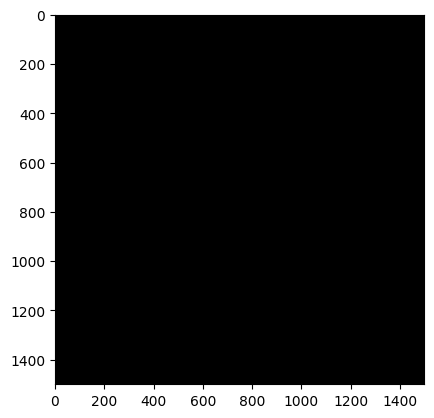

In [12]:
#create images
monkee=skimage.io.imread('/kaggle/input/imagenmonkee/fae6202d-2a8b-40e3-8d05-19f46ba7b537.ce308afc0ee1b59229142849913da8f1.jpeg')
monkee=skimage.transform.resize(monkee,(250,250))
img=monkee
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
#create 1500x1500 canvas
canvas=np.zeros((1500,1500,3))
x=750-monkee.shape[0]/2
resnetimages=[]
ys=[]
for i in range(3):
    y=random.randint(0,1000)
    canvas[int(y):int(y)+monkee.shape[0],int(x):int(x)+monkee.shape[1]]=monkee
    yinfivesec=y+(1/2)*9.8*5**2
    ys.append(yinfivesec)
    resnetimages.append(preprocess(canvas))
    canvas=np.zeros((1500,1500,3))




plt.imshow(canvas)

In [13]:

class game():
  def __init__(self):
    self.x=450

  def reset(self):
    self.x=450
    self.y=0
    self.canvas = np.zeros((1500, 1500,3))
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    print(self.canvas.shape)
    #resize image
    self.canvas=preprocess(self.canvas)
    self.canvas=torch.unsqueeze(self.canvas,0)
    return self.canvas,0,False,{}
  def step(self,action):
    self.canvas=np.zeros((1500,1500,3))
    print(self.y)
    freefall=self.y+(1/2)*9.8*(2)**2
    print("yfuture")
    print(freefall)

    self.y=freefall
    if self.y>1500-250:
      done=True
      return torch.unsqueeze(preprocess(self.canvas),0),1,done,{}
    else:
      done=False
    self.y=int(freefall)
    print()
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    #resize image
    stateaf=preprocess(self.canvas)
    stateaf=torch.unsqueeze(stateaf,0)
    reward=self.reward(action)
    info={}
    return stateaf,reward,done,info


  def reward(self,action):
    print((self.y,action))
    return -torch.nn.functional.mse_loss(torch.tensor(action),torch.tensor(self.y))

## 3. Model definition (original style preserved)

_Original code below, unchanged._


In [14]:
class ResBlock(torch.nn.Module):
  def __init__(self,inn,outt,downsample):
    super(ResBlock,self).__init__()
    self.conv1=torch.nn.Conv2d(inn,outt,3,padding=1)
    self.batchnorm1=torch.nn.BatchNorm2d(outt)
    self.relu=torch.nn.ReLU()

    self.downsample = downsample
    self.avgpool=torch.nn.AvgPool2d(2,2)
    if self.downsample or inn != outt:
            self.identity_downsample = nn.Conv2d(inn, outt, kernel_size=1, stride=1)
            self.identity_batchnorm = nn.BatchNorm2d(outt)
    else:
            self.identity_downsample = None
  def forward(self,x):
    residual=self.conv1(x)
    residual=self.batchnorm1(residual)
    residual=self.relu(residual)
    identity = x
    #print("identity shape")
    #print(identity.shape)
    #print("residual shape")
    #print(residual.shape)
    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)
        #print("identity shape2")
        #print(identity.shape)
        identity = self.identity_batchnorm(identity)

        # Add residual and identity
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output
    else:
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output

    return output




In [15]:
class actorr(torch.nn.Module):
    def __init__(self):
        super(actorr,self).__init__()
        self.resBlock1=ResBlock(3,32,True)
        self.resBlock2=ResBlock(32,32,True)
        self.resBlock3=ResBlock(32,64,True)
        self.resBlock4=ResBlock(64,64,True)
        #self.resnet=resnet18(pretrained=False)
        #self.vgg=torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)

        #self.vgg=torch.nn.Sequential(*list(self.vgg.children())[:-1])
        self.flatten=torch.nn.Flatten()
        self.fcmean=torch.nn.Linear(100,1)
        self.fcvar=torch.nn.Linear(12544,200)
        self.fcvar2=torch.nn.Linear(200,100)
        self.fcvar3=torch.nn.Linear(100,50)
        self.fcvar4=torch.nn.Linear(50,1)
        #self.instancenorm3=torch.nn.RMSNorm((1,200),elementwise_affine=True)
        #self.instancenorm2=torch.nn.RMSNorm((1,100),elementwise_affine=True)
        #self.instancenorm1=torch.nn.RMSNorm((1,200),elementwise_affine=True)
        #self.groupnorm1=torch.nn.GroupNorm(num_groups=32,num_channels=512)
        self.selu1=torch.nn.SELU()
        self.selu2=torch.nn.SELU()
        self.selu3=torch.nn.SELU()
        self.sigmoid=torch.nn.Sigmoid()
        #self.limit=limit
        #initialize fc
        #torch.nn.init.xavier_uniform_(self.fcmean.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar2.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar3.weight)
        #remove last fc layer withou
        #self.resnet.fc=torch.nn.Identity()
        #self.vgg.classifier=torch.nn.Identity()


        #for param in self.resnet.parameters():
            #param.requires_grad = False
        #unfreeze with a probability
        #for param in self.resnet.parameters():
            #delta=random.random()
            #if delta<self.limit:
                #param.requires_grad = True
        #self.resnet.layer4.requires_grad_(True)
        #self.resnet.layer3.requires_grad_(True)
        #self.resnet.layer2.requires_grad_(True)
        #self.resnet.layer1.requires_grad_(True)
        #for param in self.vgg.parameters():
            #param.requires_grad = False
        for name, param in self.named_parameters():
          print(f"Parameter: {name} | requires_grad: {param.requires_grad}")



    def forward(self,x):
        x=self.resBlock1(x)
        x=self.resBlock2(x)
        x=self.resBlock3(x)
        x=self.resBlock4(x)
        #x=self.vgg(x)
        #x=self.groupnorm1(x)
        #print("ex sheip")
        #print(x.shape)
        x=self.flatten(x)


        x=self.fcvar(x)
        #x=self.instancenorm1(x)
        #print("shapefif")
        #print(x.shape)
        #dinamic instance
        #x=torch.reshape(x,(-1,1,200))
        #tensorrr=torch.Tensor([])
        #for i in x:
          #print(i.shape)


          #i=self.instancenorm1(i)
          #concat
          #tensorrr=torch.cat((tensorrr,i),0)
        #x=tensorrr

        #x=torch.reshape(x,(-1,200))
        #x=self.selu1(x)
        x=torch.nn.LeakyReLU()(x)

        #x=torch.nn.Dropout(0.5)(x)

        #x=tensorr
        x=self.fcvar2(x)
        #x=torch.nn.InstanceNorm1d(x.shape[0])(x)
        #x=self.selu2(x)
        x=torch.nn.LeakyReLU()(x)

        #x=torch.nn.Dropout(0.5)(x)
        #x=self.instancenorm2(x)
        #x=self.selu2(x)
        variance=self.fcvar3(x)
        variance=torch.nn.LeakyReLU()(variance)
        variance=self.fcvar4(variance)
        mean=self.fcmean(x)
        #mean=torch.nn.Sigmoid()(mean)
        bruh=torch.cat((mean,variance),1)

        #concat the mean and variance
        #x=self.instancenorm3(x)
        #x=self.sigmoid(x)


        #x=torch.nn.ReLU6()(x)





        return bruh
    def act(self,x,eps,deterministic):
        #print("input sheip")
        #print(x.shape)

        x=self.forward(x)
        #print("mean and std")


        #static variance
        variance=torch.abs(x[:,1])+1e-5
        #variance=torch.ones(x.shape[0])
        #variance=torch.exp(variance)
        #variance=torch.clamp(variance,0.2,1)
        variance=torch.reshape(variance,(-1,1))

        print(x[:,0])
        #print(x[:,1])
        #clampvar

        cov=torch.diag(variance)
        dist=torch.distributions.Normal(x[:,0],variance)
        if deterministic:
            action=x[:,0]*1500
            return action,0,0,action
        action=dist.rsample()
        action=torch.reshape(action,(-1,1))
        #print("action")
        #print(action)


        log_prob=dist.log_prob(action)
        log_prob=log_prob
        actionunscaled=action
        action=torch.nn.Sigmoid()(action)*1500
        #print("log prob")
        #print(log_prob)
        entropy=dist.entropy()
        entropy=torch.mean(entropy)
        #print("entropy")
        #print(entropy)
        log_prob=torch.reshape(log_prob,(-1,1))
        if deterministic:
            #print("deterministaaaa")
            action=x[:,0]*1500
            #print("action determinista")
            #print(action)


        return action,log_prob,entropy,actionunscaled,x[:,0],x[:,1]
    def actonlogprob(self,x,eps,deterministic,actions):
      meaandavg=torch.Tensor([])
      print("input sheip")
      print(x.shape)
      for i in x:
        i=torch.unsqueeze(i,0)

        i=self.forward(i)
        #print("actionss")
        #print(actions)
        meaandavg=torch.cat((meaandavg,i),0)
      x=meaandavg
      #static variance
      variance=x[:,1]*10+1e-5
      #x=self.forward(x)
      #variance=torch.ones(x.shape[0])
      variance=torch.clamp(variance,min=1e-3,max=1.0*eps)
      dist=torch.distributions.Normal(x[:,0],variance)
      logprobs=dist.log_prob(actions)
      logprobs=logprobs
      entropy=dist.entropy()
      entropy=torch.mean(entropy)
      #print("logprobs")
      #print(logprobs)
      #print("entropy")
      #print(entropy)
      #print("mean and std")
      #print(x[:,0])
      #print(x[:,1])
      graph=plt.plot(x[:,0].cpu().detach())
      #save
      #remove graph
      plt.savefig('graphmean.png')
      plt.clf()
      #plt.show()
      graph=plt.plot(x[:,1].cpu().detach())
      #save
      plt.savefig('graphstd.png')
      plt.clf()
      #plt.show()



      return logprobs,entropy

class qfunction(torch.nn.Module):
    def __init__(self):
        super(qfunction,self).__init__()
        #self.resnet=resnet18(pretrained=True)
        #self.vgg=torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)
        #self.vgg=torch.nn.Sequential(*list(self.vgg.children())[:-1])
        #self.resnet=torch.nn.Sequential(*list(self.resnet.children())[:-1])
        self.resBlock1=ResBlock(3,32,True)
        self.resBlock2=ResBlock(32,32,True)
        self.resBlock3=ResBlock(32,64,True)
        self.resBlock4=ResBlock(64,64,True)
        self.flatten=torch.nn.Flatten()
        self.fc=torch.nn.Linear(12544,100)
        self.fc1=torch.nn.Linear(101,10)
        self.fc2=torch.nn.Linear(10,1)


        self.conv1daction=torch.nn.Linear(1,32)
        self.batchnorm=torch.nn.InstanceNorm1d(32)
        self.selu=torch.nn.SELU()
        self.conv2daction=torch.nn.Linear(32,32)
        self.batchnorm2=torch.nn.InstanceNorm1d(32)
        self.convidentityaction=torch.nn.Linear(1,32)
        #initialize fc
        torch.nn.init.xavier_uniform_(self.fc.weight)
    def forward(self,x,a):
        x=self.resBlock1(x)
        x=self.resBlock2(x)
        x=self.resBlock3(x)
        x=self.resBlock4(x)
        #x=self.vgg(x)
        #x=self.resnet(x)
        x=self.flatten(x)
        x=self.fc(x)
        a=torch.nn.LeakyReLU()(a)
        x=torch.nn.LeakyReLU()(x)
        x=torch.cat((x,a),1)
        x=self.fc1(x)
        x=torch.nn.LeakyReLU()(x)
        x=self.fc2(x)
        return x

In [16]:
import random
from collections import deque
import gc
import json

In [17]:
class Train():
  def __init__(self,actor,critic,gamma,epochs,trayectories,tau,alpha):
    self.actor_losses=[]
    self.critic1_losses=[]
    self.critic2_losses=[]

    self.env=game()
    self.actor=actor()
    self.critic1=critic()
    self.critic2=critic()
    self.critictarget1=critic()
    self.critictarget2=critic()
    self.actor_optimizer=optim.SGD(self.actor.parameters(),lr=0.001)
    self.critic1_optimizer=optim.SGD(self.critic1.parameters(),lr=0.006)
    self.critic2_optimizer=optim.SGD(self.critic2.parameters(),lr=0.006)
    self.buffer=deque(maxlen=10000)
    self.batch_size=100
    self.epochs=epochs
    self.trayectoriesn=trayectories
    self.tau=tau
    self.alpha=alpha
    self.rewards=[]
    self.means=[]
    self.vars=[]
    #equal target to main
    self.critictarget1.load_state_dict(self.critic1.state_dict())
    self.critictarget2.load_state_dict(self.critic2.state_dict())
    self.gamma=gamma
  def trayectories(self,n):
    #state,reward,done,info=self.env.reset()
    for i in range(n):
      acc_reward=0
      state,reward,done,info=self.env.reset()
      self.means=[]
      self.vars=[]
      while not done:
        #state=torch.unsqueeze(state,0)
        action,_,_,_,mean,var=self.actor.act(state.cuda(),1.0,False)
        next_state,reward,done,info=self.env.step(action)
        #next_state=torch.unsqueeze(next_state,0)
        self.buffer.append((state.detach(),action.detach(),reward,next_state.detach(),done))
        state=next_state
        acc_reward+=float(reward)
        self.means.append(float(mean))
        self.vars.append(float(var))
        
      self.rewards.append(acc_reward)
      plt.plot(self.means,label="meanstrayectory")
      plt.savefig("meanpertrayectory.png")
      plt.clf()
      plt.plot(self.vars,label="varss")
      plt.savefig("varss.png")
      plt.clf()
      
      
      clear_output()
  def fit(self):
    self.trayectories(self.trayectoriesn)
    print("trayectories done")
    for i in range(self.epochs):
      print("epoch")
      print(i)
      gradients={}
      batch=random.sample(self.buffer,self.batch_size)
      states,actions,rewards,next_states,dones=zip(*batch)
      finalc1loss=0
      finalc2loss=0
      finalactloss=0

      for j in range(len(states)):
        #rewards[j]=rewards[j].detach()
        #dones[j]=dones[j].detach()
        actionsampnext=self.actor.act(next_states[j].cuda(),1.0,False)
        action,logprob,entropy,actionunscaled,_,_=actionsampnext
        y_j=rewards[j]+self.gamma*(1-int(dones[j]))*torch.min(self.critictarget1(next_states[j].cuda(),action)-self.alpha*logprob,self.critictarget2(next_states[j].cuda(),action)-self.alpha*logprob)
        qpred1=self.critic1(states[j].cuda(),actions[j])
        qpred2=self.critic2(states[j].cuda(),actions[j])
        loss_critic1=torch.nn.functional.mse_loss(qpred1,y_j)/(len(states))
        #/self.batch_size
        loss_critic2=torch.nn.functional.mse_loss(qpred2,y_j)/(len(states))
        #/self.batch_size
        loss_critic1.backward(retain_graph=True,inputs=list(self.critic1.parameters()))
        loss_critic2.backward(retain_graph=True,inputs=list(self.critic2.parameters()))
        #finalc1loss=finalc1loss+loss_critic1
        #finalc2loss=finalc2loss+loss_critic2
        #if i %5 == 0:
            
        actionreptrick=self.actor.act(states[j].cuda(),1.0,False)
        actiont,logprobt,entropyt,actionunscaledt,_,_=actionreptrick
        #logprobt=logprobt.detach()
        qpred1t=self.critic1(states[j].cuda(),actiont)
        qpred2t=self.critic2(states[j].cuda(),actiont)
        actorloss=-torch.min(qpred1t-self.alpha*logprobt,qpred2t-self.alpha*logprob)/(len(states))
        #/self.batch_size
        #finalactloss=finalactloss+actorloss
        actorloss.backward(retain_graph=True,inputs=list(self.actor.parameters()))
        #print(actorloss
        #loss_critic1.backward(retain_graph=True)
        #loss_critic2.backward(retain_graph=True)
        finalc1loss+=float(loss_critic1)
        finalc2loss+=float(loss_critic2)
        finalactloss+=float(actorloss)
        #finalactloss=torch.cat((finalactloss,actorloss),0)
        #finalc1loss=torch.cat((finalc1loss,loss_critic1),0)
        #finalc2loss=torch.cat((finalc2loss,loss_critic2),0)
        print("finished")
        clear_output()


      torch.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=3.0)
      torch.nn.utils.clip_grad_norm_(self.critic1.parameters(), max_norm=3.0)
      torch.nn.utils.clip_grad_norm_(self.critic2.parameters(), max_norm=3.0)
      self.critic1_optimizer.step()
      self.critic2_optimizer.step()
      self.actor_optimizer.step()
      for name, param in self.actor.named_parameters():
        if param.grad is not None:
          gradients[f"actor_{name}"]=str(param.grad.data.cpu().numpy())
      with open('actor_gradients.json', 'w') as f:
        json.dump(gradients, f)
      for name, param in self.critic1.named_parameters():
        if param.grad is not None:
          gradients[f"critic1_{name}"]=str(param.grad.data.cpu().numpy())
      with open('critic1_gradients.json', 'w') as f:
        json.dump(gradients, f)
      for name, param in self.critic2.named_parameters():
        if param.grad is not None:
          gradients[f"critic2_{name}"]=str(param.grad.data.cpu().numpy())
      with open('critic2_gradients.json', 'w') as f:
        json.dump(gradients, f)

      self.critic1_optimizer.zero_grad()
      self.critic2_optimizer.zero_grad()
      self.actor_optimizer.zero_grad()
      self.actor_losses.append(finalactloss)
      self.critic1_losses.append(finalc1loss)
      self.critic2_losses.append(finalc2loss)
      plt.figure(figsize=(10, 5))
      plt.plot(self.actor_losses, label='Actor Loss')
      plt.savefig('actor_loss.png')
      plt.clf()
      plt.plot(self.critic1_losses, label='Critic1 Loss')
      plt.savefig('critic1_loss.png')
      plt.clf()
      plt.plot(self.critic2_losses, label='Critic2 Loss')
      plt.savefig('critic2_loss.png')
      plt.clf()
      plt.plot(self.rewards,label="Rewards")
      plt.savefig("rewards.png")
      plt.clf()
      clear_output()
      #print gradients
      #gc.collect()
      #del finalc1loss
      #del finalc2loss
      #del finalactloss
      #del loss_critic1
      #del loss_critic2
      #del actorloss
      #del qpred
      #del qpred1t
      #del qpred2t
      #del actiont
      #del logprobt
      #del entropyt
      #del actionunscaledt
      #del actionreptrick
      #del action
      #del logprob
      #del entropy
      #del actionunscaled
      self.update()

  def update(self):
    with torch.no_grad():
      for param, target_param in zip(self.critic1.parameters(), self.critictarget1.parameters()):
          target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
      for param, target_param in zip(self.critic2.parameters(), self.critictarget2.parameters()):
          target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)









In [ ]:

trainn=Train(actorr,qfunction,0.99,3,2,0.1,0.8)
for i in range(1000):
  trainn.fit()

(1500, 1500, 3)
tensor([-1.4954], grad_fn=<SelectBackward0>)
0
yfuture
19.6

(19, tensor([[309.6629]], grad_fn=<MulBackward0>))
tensor([-1.6232], grad_fn=<SelectBackward0>)
19
yfuture
38.6

(38, tensor([[233.0280]], grad_fn=<MulBackward0>))
tensor([-1.7291], grad_fn=<SelectBackward0>)
38
yfuture
57.6

(57, tensor([[201.0275]], grad_fn=<MulBackward0>))
tensor([-1.8392], grad_fn=<SelectBackward0>)
57
yfuture
76.6

(76, tensor([[202.3896]], grad_fn=<MulBackward0>))
tensor([-1.9091], grad_fn=<SelectBackward0>)
76
yfuture
95.6

(95, tensor([[207.8266]], grad_fn=<MulBackward0>))
tensor([-1.9396], grad_fn=<SelectBackward0>)
95
yfuture
114.6

(114, tensor([[174.0874]], grad_fn=<MulBackward0>))
tensor([-1.9631], grad_fn=<SelectBackward0>)
114
yfuture
133.6

(133, tensor([[234.5986]], grad_fn=<MulBackward0>))
tensor([-2.0072], grad_fn=<SelectBackward0>)
133
yfuture
152.6

(152, tensor([[227.7570]], grad_fn=<MulBackward0>))
tensor([-2.0233], grad_fn=<SelectBackward0>)
152
yfuture
171.6

(171, ten